dodaj info o 1pkt za zrobienie na prawdziwym obrazku.
popraw zadania o copy

# Lista 2

## Numpy podstawy

(9pkt + 3pkt)

Na liście znajduje się 9 zadań do wykonania w trakcie zajęć. Po rozwiązaniu zadania pokaż kod prowadzącemu i odpowiedz na **pytanie kontrolne** (są one podane przy każdym zadaniu) — wtedy przyznajemy punkt. Dodatkowo prześlij zadanie na platformie skos.

Jeśli w poleceniu nie jest wskazane użycie pętli `for` - nie korzystaj z niej.

Zadania dodatkowe są oznaczone ⭐️. To zadani o numerach 10 i 11. Dodatkowo moeżesz otrzymać 1pkt z puli punktów bonusowych jeśli wykonasz wszystkie poniższe zadania związane z obrazami na prawdziwym obrazku.

Kazde zadnanie warte jest 1pkt.

## 1. Analiza pikseli obrazu

**Kontekst:** W AI obrazy to tablice NumPy (np. `H×W×C`). Proste operacje na obrazach można robić wektorowo bez pętli.

**Polecenie**

* Utwórz przykładową tablicę 3×3 obrazu RGB zawierającą wartości 0–255.
* Zwiększ jasność o 10% — ale **nie przekraczaj 255** (`np.clip`).
* Pokaż wynik i typ danych.

**Podpowiedź**
Zwiększ jasność obrazu mnożąc każde pasmo RGB przez 110%. 

In [1]:
import numpy as np

A = np.array([
    [[100, 150, 200], # first row of pixels
     [50, 100, 150],
     [0, 50, 100]],
    
    [[200, 100, 50], # second row 
     [255, 200, 150],
     [100, 0, 50]],
    
    [[25, 75, 125], # third row
     [175, 225, 255],
     [80, 160, 240]]
])

bright = np.clip(A * 1.1, 0, 255)

print("Oryginał:\n", A)
print("\nPo zwiększeniu jasności o 10%:\n", bright)
print("\nTyp danych:", bright.dtype)


Oryginał:
 [[[100 150 200]
  [ 50 100 150]
  [  0  50 100]]

 [[200 100  50]
  [255 200 150]
  [100   0  50]]

 [[ 25  75 125]
  [175 225 255]
  [ 80 160 240]]]

Po zwiększeniu jasności o 10%:
 [[[110.  165.  220. ]
  [ 55.  110.  165. ]
  [  0.   55.  110. ]]

 [[220.  110.   55. ]
  [255.  220.  165. ]
  [110.    0.   55. ]]

 [[ 27.5  82.5 137.5]
  [192.5 247.5 255. ]
  [ 88.  176.  255. ]]]

Typ danych: float64


## 2. Normalizacja danych wejściowych

**Kontekst:** Dane wejściowe do modeli zazwyczaj normujemy — albo do `[0,1]`, albo standaryzujemy do średniej 0 i odchylenia 1.

**Polecenie**

* Wygeneruj 1D tablicę 100 losowych liczb w przedziale `0..255`.
* Przeskaluj na `[0,1]`.
* Następnie stwórz znormalizowaną wersję z średnią 0 i odchyleniem 1 (standaryzacja).
* Nie używaj pętli.

**Pytanie kontrolne:** Co się stanie, gdy `std == 0`?

In [2]:
import numpy as np

x = np.random.randint(0, 256, size=100)
x_scaled = x / 255
mean = np.mean(x)
std = np.std(x)
x_standardized = (x - mean) / std if std != 0 else np.zeros_like(x)

print("mean scaled:", np.mean(x_scaled))
print("mean standardized:", np.mean(x_standardized))
print("std standardized:", np.std(x_standardized))

# jeśli std = 0 - to oznaczałoby to, że nie ma odchylenia, czyli wszystkie dane sa takie same - 
# dla sredniej znormalizowanej rownej 0, oznaczaloby to ze wszystkie dane to zera

mean scaled: 0.4865882352941176
mean standardized: 2.831068712794149e-17
std standardized: 0.9999999999999998


## 3. Wycinanie fragmentów danych

**Kontekst:** Często dzielimy długi sygnał na krótsze okna (np. do ekstrakcji cech).

**Polecenie**

* Stwórz 1D tablicę długości 1000 (np. `np.arange(1000)`).
* Podziel ją na 10 fragmentów po 100 elementów (`reshape`).
* Oblicz średnią każdego fragmentu (wektor 10-elementowy).

**Pytanie kontrolne:** Co policzymy jeśli obliczymy `axis=0`?

In [3]:
import numpy as np

x = np.arange(1000)
chunks = x.reshape(10, 100)   # 10 x 100 elementów
means = np.mean(chunks, axis=1) # średnia dla każdego z 10 wierszy

print("shape chunks:", chunks.shape)
print("means:", means)
# axis = 0, oznaczałoby średnia z każdej kolumny, czyli 100 średnich po 10 elementów

shape chunks: (10, 100)
means: [ 49.5 149.5 249.5 349.5 449.5 549.5 649.5 749.5 849.5 949.5]


## 4. Operacje wzdłuż osi

**Kontekst:** Przy normalizacjach i agregacjach często operujemy wzdłuż konkretnej osi.

**Polecenie**

* Utwórz `X = np.random.randint(0, 100, (5,4))`.
* Oblicz:

  * min każdego wiersza używając `X.min(...)`
  * max każdej kolumny używając `X.max(...)`
* Znormalizuj każdy wiersz tak, aby suma elementów w wierszu była równa 1. Sprawdź poprawność rozwiązania sumując wartości w każdym wierszu.

In [4]:
import numpy as np

X = np.random.randint(0, 100, (5, 4)) # macierz 5 x 4 z losowymi wartościami od 0 do 99
row_mins = X.min(axis=1)
col_maxs = X.max(axis=0)

row_sums = X.sum(axis=1, keepdims=True) # keepdims=True -> shape (5,1)
X_norm = X / row_sums

print("X:\n", X)
print("\nrow_mins:", row_mins)
print("col_maxs:", col_maxs)
print("\nSuma wierszy po normalizacji:", X_norm.sum(axis=1))


X:
 [[ 8 31 38 74]
 [ 2 20 80 90]
 [55 27 73 77]
 [73 51 74 95]
 [29 69 39 43]]

row_mins: [ 8  2 27 51 29]
col_maxs: [73 69 80 95]

Suma wierszy po normalizacji: [1. 1. 1. 1. 1.]


## 5. Analiza embeddingów słów

**Kontekst:** W NLP słowa reprezentujemy wektorami (embeddingi). Często chcemy średnią reprezentację zdania i podobieństwo kosinusowe.

**Polecenie**

* Stwórz macierz `E` o kształcie `(5,50)` — 5 embeddingów po 50 wymiarów (`np.random.randn`).
* Oblicz:

  * `mean_embedding` (średni wektor po wierszach)
  * macierz podobieństw kosinusowych między wszystkimi parami wektorów (5×5)

**Pytanie kontrolne:** Jak interpretujesz wartości w `cosine_sim` (zakres i znaczenie)?

---

### Wskazówka

Zastanów się, jak można obliczyć **podobieństwo kosinusowe** dwóch wektorów `a` i `b`, jeśli wiesz, że:

$$
\cos(\theta) = \frac{a \cdot b}{|a| \cdot |b|}
$$

Spróbuj najpierw policzyć to dla jednej pary wektorów w NumPy,
używając `np.dot()` i `np.linalg.norm()`.

A następnie pomyśl:

* Jak znormalizować wszystkie wektory jednocześnie, żeby każdy miał długość 1?
* Jak wykorzystać mnożenie macierzy (`@`), żeby w jednym kroku dostać podobieństwa między wszystkimi parami wektorów (5×5)?

In [5]:
import numpy as np

E = np.random.rand(5, 50)

# średni wektor (embedding zdania) - po wierszach
mean_embedding = np.mean(E, axis=0)

# normalizacja wektorów do długości 1
norms = np.linalg.norm(E, axis=1, keepdims=True)
E_normalized = E / norms

# macierz podobieństw kosinusowych = E_norm @ E_norm.T
cosine_sim = E_normalized @ E_normalized.T

print("mean_embedding shape:", mean_embedding.shape)
print("cosine_sim shape:", cosine_sim.shape)
print("cosine_sim (przykład):\n", cosine_sim)

mean_embedding shape: (50,)
cosine_sim shape: (5, 5)
cosine_sim (przykład):
 [[1.         0.74636597 0.76363878 0.70522347 0.71101527]
 [0.74636597 1.         0.82031116 0.7811179  0.71683883]
 [0.76363878 0.82031116 1.         0.81890047 0.76183324]
 [0.70522347 0.7811179  0.81890047 1.         0.7638664 ]
 [0.71101527 0.71683883 0.76183324 0.7638664  1.        ]]


## 6. Sklejanie sensorów — dane z pojazdu autonomicznego

**Kontekst:** Dane z różnych sensorów różnią się formatem — trzeba je połączyć w jedną macierz cech.

**Polecenie**

* Stwórz:

  ```python
  lidar = np.random.rand(100, 2)   # x,y # lidar - Light Detection and Ranging
  camera = np.random.rand(100, 1)  # jasność
  radar = np.random.rand(100, 1)   # prędkość
  ```
* Połącz je kolumnowo w macierz `X` o kształcie `(100,4)`.
* Podziel `X` na `train` (80%) i `test` (20%) (np. `np.array_split` lub indeksowanie).
* Oblicz średnią jasność i średnią prędkość dla obu zestawów.

**Pytanie kontrolne:** Dlaczego warto przetasować dane (shuffle) przed splitem w prawdziwym pipeline?

In [9]:
import numpy as np

lidar = np.random.rand(100, 2)   # x,y
camera = np.random.rand(100, 1)  # jasność
radar = np.random.rand(100, 1)   # prędkość

X = np.hstack([lidar, camera, radar])
assert X.shape == (100, 4)

# split train/test (bez shuffle dla prostoty)
n_train = int(0.8 * len(X))
train, test = X[:n_train], X[n_train:]

# indeksy kolumn: camera -> 2, radar -> 3 (0-based)
mean_camera_train = train[:, 2].mean() # [wiersze, kolumny] -> [:, 2] -> wszystkie wiersze i 3 kolumna
mean_radar_train  = train[:, 3].mean()
mean_camera_test  = test[:, 2].mean()
mean_radar_test   = test[:, 3].mean()

print("X.shape:", X.shape)
print("train/test shapes:", train.shape, test.shape)
print("mean camera train/test:", mean_camera_train, mean_camera_test)
print("mean radar train/test:", mean_radar_train, mean_radar_test)

# Warto przetasować, ponieważ dane na wejściu są często poszeregowane np. czasowo
# bez tego dane treningowe mogą być słabo dokładne

X.shape: (100, 4)
train/test shapes: (80, 4) (20, 4)
mean camera train/test: 0.5419910967390749 0.4702018115747363
mean radar train/test: 0.5163512690492151 0.5268202764313533


## 7. NumPy vs. czysty Python

**Kontekst:** NumPy działa o wiele szybciej niż pętle Pythonowe dla operacji numerycznych. Tu wykorzystamy `np.linspace`.

**Polecenie**

* Stwórz `x = np.linspace(0, 1, 10_000_000)`.
* Oblicz `s = sin(x)**2 + cos(x)**2`:

  * a) w czystym Pythonie (pętla `for` i `math.sin`, `math.cos`)
  * b) w NumPy (`np.sin`, `np.cos` — wektoryzacja)
* Porównaj czasy wykonania (wskazane: `%timeit` w notebooku lub `time.time()`).

In [11]:
import numpy as np
import math
import time

# dane
x = np.linspace(0, 1, 10_000_000)

# NumPy version
t0 = time.time()
y_np = np.sin(x)**2 + np.cos(x)**2
t_np = time.time() - t0

# Python loop version (bardzo wolne; uruchamiaj ostrożnie; jak trwa dłuej ni 15s, to przerwij i zmniejsz przykład)
t0 = time.time()
s = 0.0
for xi in x:           
    s += math.sin(xi)**2 + math.cos(xi)**2
t_py = time.time() - t0

print(f"NumPy time: {t_np:.3f}s")
print(f"Pure Python loop time: {t_py:.3f}s")

NumPy time: 0.383s
Pure Python loop time: 4.334s


## 8. Copy, View

**Kontekst:** Podczas preprocessingu zespoły czasami pracują na tym samym obiekcie myśląc, że mają kopię — to prowadzi do skażenia danych.

**Polecenie**

* Stwórz `patients = np.random.randint(60, 120, (5, 4))`.
  * `doctors_view`, gdzie doktor będzie przeglądał tylko co drugi pomiar,
  * `research_copy`, czyli kopię patients.
* Lekarz przez pomyłkę wykona `doctors_view[:] = -1`.
* Sprawdź, czy `patients` się zmieniło i czy `research_copy` pozostało bez zmian. Wyjaśnij.

**Pytanie kontrolne:** W jaki sposób zabezpieczyć workflow, żeby przypadkowe zmiany nie wpływały na bazę danych?

In [15]:
import numpy as np

patients = np.random.randint(60, 120, (5, 4))
doctors_view = patients[:, ::2]
research_copy = patients.copy()

print("przed zmiana:\n", patients)
doctors_view[:] = -1
print("po zmianie doctors_view:\n", patients)
print("research_copy (czy zmienione?):\n", research_copy)

# wykrywamy, które są view / copy
print("doctors_view.base is patients?", doctors_view.base is patients)
print("research_copy.base is patients?", research_copy.base is patients)

# Dobrze jest trzymać oryginał niezmieniony i pracować na kopiach (używać .copy())
# Oryginał można nawet jako readonly po wykonaniu kopii

przed zmiana:
 [[ 67  61  89 116]
 [ 93  95 116  78]
 [115  74 106 100]
 [ 70  90  87  81]
 [111  64  65 109]]
po zmianie doctors_view:
 [[ -1  61  -1 116]
 [ -1  95  -1  78]
 [ -1  74  -1 100]
 [ -1  90  -1  81]
 [ -1  64  -1 109]]
research_copy (czy zmienione?):
 [[ 67  61  89 116]
 [ 93  95 116  78]
 [115  74 106 100]
 [ 70  90  87  81]
 [111  64  65 109]]
doctors_view.base is patients? True
research_copy.base is patients? False


## 9. Jak CNN „przesuwa okno” po obrazie?

**Kontekst:** W konwolucyjnej sieci neuronowej filtr (np. 3×3) „przesuwa się” po obrazie piksel po pikselu. Parametr stride określa, o ile pikseli filtr przesuwa się w pamięci między kolejnymi pozycjami. Zrozumienie, jak numpy.strides działa, pozwala intuicyjnie pojąć, dlaczego operacja konwolucji może być wydajna bez kopiowania danych.

**Polecenie**

1. Utwórz: `A = np.arange(1,13).reshape(3,4)` — traktuj jako obraz `3 × 4`, oraz `AT = A.T`.
2. Wypisz: `A`, `A.strides`, `AT`, `AT.strides`.
3. Oblicz ile bajtów trzeba przeskoczyć, aby dotrzeć:
   * od `A[0,0]` do `A[0,1]`,
   * od `A[0,0]` do `A[1,0]`.
4. Sprawdź, czy `AT` jest widokiem (`AT.base is A`), zmień `A[0,0] = -99` i sprawdź `AT`.
5. Napisz funkcję `memory_offset(A, i, j)`, która obliczy ile bajtów trzeba przejść od `A[0][0]` do miejsca `A[i][j]`
   Użyj jej, żeby policzyć offsety kilku elementów w `A` i `A.T`. Zinterpretuj wyniki.

**Pytanie kontrolne:** Wyjaśnij własnymi słowami: co się stanie jak zmienisz `strides`?

In [19]:
import numpy as np

A = np.arange(1, 13).reshape(3, 4)
print("A:\n", A)
print("A.strides:", A.strides) 

AT = A.T
print("AT:\n", AT)
print("AT.strides:", AT.strides)

# elementsize (liczba bajtów na element)
bs = A.itemsize
print("itemsize (bajtów per element):", bs)

# obliczenia ręczne:
offset_A_00_to_01 = A.strides[1] # w kolumnie
offset_A_00_to_10 = A.strides[0] # w wierszu
print("offset A[0,0] -> A[0,1] (bajtów):", offset_A_00_to_01)
print("offset A[0,0] -> A[1,0] (bajtów):", offset_A_00_to_10)

# sprawdzenie widoku
print("A.T.base is A ?", AT is A)
print(AT.flags)
# zmiana A i obserwacja AT
A[0,0] = -99
print("A po zmianie:\n", A)
print("A.T po zmianie:\n", AT)

# funkcja memory_offset
def memory_offset(M, i, j):
    return M.strides[0] * i + M.strides[1] * j

print("memory offset A[2,3]:", memory_offset(A, 2, 3))
print("memory offset AT[2,3]:", memory_offset(AT, 2, 3))

# Zmieniając stride, zmieniamy interpretacje danych - to jak będą odczytywane z pamięci
# Przez to - jeśli będą zmienione w błędny sposób - to będą źle odczytywane

A:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
A.strides: (32, 8)
AT:
 [[ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]
 [ 4  8 12]]
AT.strides: (8, 32)
itemsize (bajtów per element): 8
offset A[0,0] -> A[0,1] (bajtów): 8
offset A[0,0] -> A[1,0] (bajtów): 32
A.T.base is A ? False
  C_CONTIGUOUS : False
  F_CONTIGUOUS : True
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

A po zmianie:
 [[-99   2   3   4]
 [  5   6   7   8]
 [  9  10  11  12]]
A.T po zmianie:
 [[-99   5   9]
 [  2   6  10]
 [  3   7  11]
 [  4   8  12]]
memory offset A[2,3]: 88
memory offset AT[2,3]: 112


## 10. ⭐️ Zaawansowana augmentacja i analiza obrazów RGB

**Kontekst:** Przy trenowaniu CNN operujemy na obrazach RGB. Często robimy augmentacje (jasność, kontrast, rotacje, przesunięcia) i porównujemy obrazy np. za pomocą **cosine similarity**. Trzeba uważać, które operacje zwracają **widok**, a które **kopię**, aby nie psuć danych przez przypadek.

**Polecenie**

1. Wygeneruj **10 losowych obrazów RGB**, każdy o wymiarach `32×32×3` z wartościami `uint8` (0–255).
2. Napisz funkcję `cosine_similarity(img1, img2)`, która oblicza podobieństwo kosinusowe między dwoma obrazami traktowanymi jako wektory.
3. Stwórz funkcję `augment(img)` która tworzy warianty obrazu:

   * oryginał,
   * flip poziomy,
   * flip pionowy,
   * rotacja 90°,
   * jaśniejsza wersja,
   * wersja z większym kontrastem,
   * mały przesunięty fragment (crop + pad),
   * zamiana kanałów RGB na BGR.
4. Dla każdego wariantu sprawdź, które są **widokiem**, a które **kopią** (`.base`).
5. Oblicz macierz podobieństwa kosinusowego między wszystkimi 10 obrazami oryginalnymi i wypisz średnie podobieństwo.
6. Oblicz podobieństwo między oryginałami a ich wariantami i sprawdź, które operacje najbardziej zmieniają obraz (najmniejsze cosine similarity).   

original -> COPY
flip_horizontal -> VIEW
flip_vertical -> VIEW
rotate90 -> VIEW
brighter -> COPY
high_contrast -> COPY
crop_pad -> COPY
bgr -> VIEW
Mean similarity between randomly generated images = -2.6999999999999997
\Image #1
original: 1.0000
flip_horizontal: 0.7510
flip_vertical: 0.7558
rotate90: 0.7572
brighter: 0.7832
high_contrast: 0.8407
crop_pad: 0.8701
bgr: 0.8322
\Image #2
original: 1.0000
flip_horizontal: 0.7602
flip_vertical: 0.7645
rotate90: 0.7587
brighter: 0.8021
high_contrast: 0.8462
crop_pad: 0.8801
bgr: 0.8449
\Image #3
original: 1.0000
flip_horizontal: 0.7587
flip_vertical: 0.7420
rotate90: 0.7564
brighter: 0.8047
high_contrast: 0.8390
crop_pad: 0.8757
bgr: 0.8408
\Image #4
original: 1.0000
flip_horizontal: 0.7379
flip_vertical: 0.7575
rotate90: 0.7524
brighter: 0.8115
high_contrast: 0.8378
crop_pad: 0.8775
bgr: 0.8373
\Image #5
original: 1.0000
flip_horizontal: 0.7509
flip_vertical: 0.7373
rotate90: 0.7452
brighter: 0.7980
high_contrast: 0.8378
crop_pad: 0.8748
bg

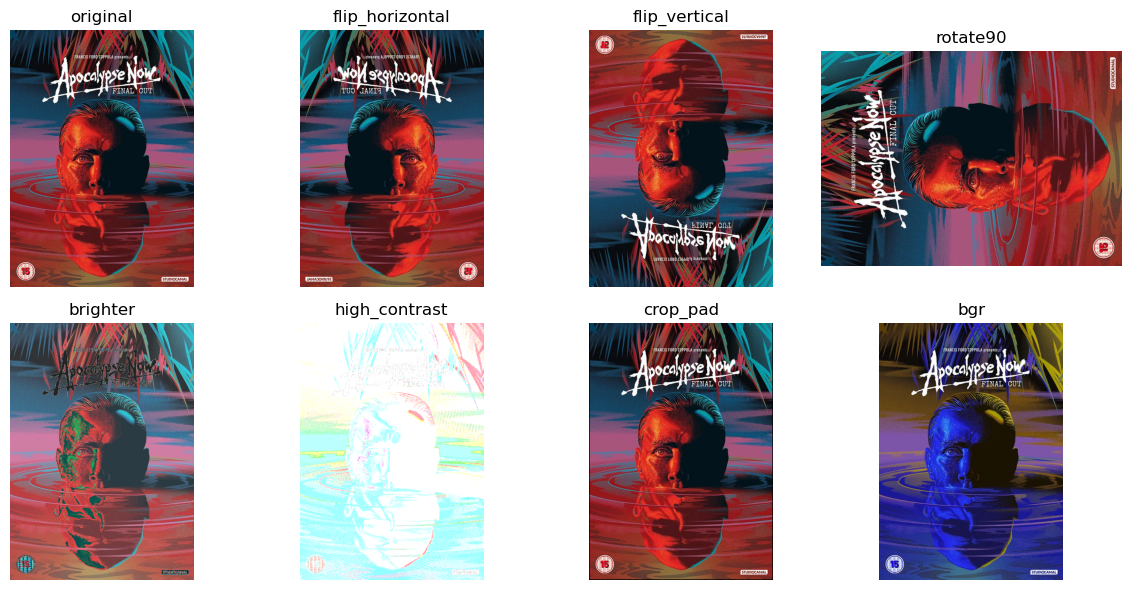

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

images = [np.random.randint(0, 256, (32, 32, 3), dtype=np.uint8) for _ in range(10)]
real_image = np.array(Image.open("apocalypse.jpg").convert("RGB"), dtype=np.uint8)

def cosine_similarity(img1, img2):
    # Cast image to 1D vector
    y1 = img1.astype(np.int32).ravel()
    y2 = img2.astype(np.int32).ravel()
    # Podobieństwo cosinusowe to policzenie cosinusa kąta między wektorami tak żeby 
    # oszacować jak bardzo podobny jest ich zwrot 
    # cos = iloczyn skalarny y1 i y2 / ich normy (długości) pomnożone przez siebie
    return np.dot(y1, y2) / (np.linalg.norm(y1) * np.linalg.norm(y2))

def augment(img):
    return {
        "original"        : img,
        "flip_horizontal" : np.fliplr(img),
        "flip_vertical"   : np.flipud(img),
        "rotate90"        : np.rot90(img),
        "brighter"        : np.clip(img + 40, 0, 255).astype(np.uint8),
        "high_contrast"   : np.clip(1.5 * (img - 128) + 128, 0, 255).astype(np.uint8),
        "crop_pad"        : np.pad(img[2:-2, 2:-2, :], ((2,2),(2,2),(0,0)), mode="constant"),
        "bgr"             : img[..., ::-1]
    }
    
example = images[0]
augmented = augment(example)
real_augmented = augment(real_image)
for name, var in augmented.items():
    print(f"{name} -> {'VIEW' if var.base is example else 'COPY'}")
    # Dlaczego original -> COPY?
similarity_matrix = np.zeros((10, 10), dtype=np.int32)
for i in range(10):
    for j in range(10):
        similarity_matrix[i, j] = cosine_similarity(images[i], images[j])

mean_similarity = (np.sum(similarity_matrix) - 10) / 10 * 9
print(f"Mean similarity between randomly generated images = {mean_similarity}")

for idx, img in enumerate(images):
    variants = augment(img)
    print(f"\Image #{idx+1}")
    for name, var in variants.items():
        sim = cosine_similarity(img, var)
        print(f"{name}: {sim:.4f}")

plt.figure(figsize=(12, 6))
for i, (name, var) in enumerate(real_augmented.items(), 1):
    plt.subplot(2, 4, i)
    plt.imshow(var)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 11. ⭐️ Świadome kopiowanie

**Kontekst**
Pracujesz z dużymi macierzami w Pythonie/NumPy, które reprezentują np. wyniki eksperymentów, symulacje lub dane użytkowników.

**Polecenie**
Twoim zadaniem jest zdecydować w jaki sposób należy **modyfikować dane**, w miejscu, w kopii, czy wystarczy widok? A może trzeba użyć deepcopy? Rozważ dwa przypadki - kiedy używasz biblioteki `numpy` i `copy`. Odpowiedz na wszystkie pytania. W każdej części musisz **uzasadnić wybór metody**.

Na początku stwórz dwuwymiarową tablicę `M`, na której będziesz demonstrować i uzasadniać użycie wybranej metody.

#### **a) Lokalna korekta**

Wartość w komórce `[0,0]` jest błędna i powinna być `1`.

* Jak poprawisz tę wartość?
* Czy zmieniasz oryginał, czy tworzysz kopię?
* Jak działa pamięć w tym przypadku?

#### **b) Alternatywna wersja danych**

Chcesz stworzyć **zmodyfikowaną wersję danych**, np. w kolumnie 2 przeskalować wszystkie wartości, w celu przeprowadzenia eksperymentu.

* Zastanów się, czy potrzebujesz `view`, `copy` czy `deepcopy`.
* Przetestuj różne podejścia (`M.view()`, `M.copy()`) i sprawdź, co się dzieje po modyfikacji nowej macierzy.

#### **c) Symulacje z listą zagnieżdżoną**

Tworzysz listę eksperymentów:

```python
L = [M, M.copy()]
```

Teraz chcesz **przeprowadzić symulacje zmian**, np. dodając losowe wartości, **bez zmiany oryginału** ani kopii w `L`.

* Jakiego rodzaju kopiowania użyjesz?
* Co się stanie, jeśli użyjesz tylko `copy` zamiast `deepcopy`, gdy struktura jest zagnieżdżona?

#### **d) Podzbiór kolumn**

Wybierasz podzbiór kolumn np. 1 i 3:

```python
subset = M[:, [1, 3]]
```

* Sprawdź, czy zmiany w `subset` wpływają na `M`.
* Porównaj to z cięciem typu `subset = M[:, 1:3]`.

In [14]:
import numpy as np
import copy 

M = np.arange(16).reshape(4, 4)
# a)
# Jak zmienisz wartość?
M[0, 0] = 1
# Oryginał czy kopia? - Na oryginale, bo wartość jest błędna
# Jak działa pamięć? - Tablica M to 16 kolejnych miejsc w pamięci

# b)
# copy wystarczy
Mview = M.view()
Mcopy = M.copy()

Mcopy[:, 1] *= 2
print("M po zmianie kopii: \n", M) # kopia to oddzielne miejsce w pamięci

Mview[:, 1] *= 2
print("M po zmianie widoku: \n", M)

# c)
L = [M, M.copy()]
# L_sim = copy.copy(L) - płytka kopia listy, czyli tylko odniesienie do listy jest kopiowane, ale wartości w nich obu są te same
L_deep = copy.deepcopy(L) # poprawne kopiowanie zagnieżdżone

# d)
subset1 = M[:, [1, 3]]
subset1[0, 0] = 977
print("M po zmianie subset1: \n", M)

subset2 = M[:, 1:3]
subset2[0, 0] = 977
print("M po zmianie subset1: \n", M)

M po zmianie kopii: 
 [[ 1  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
M po zmianie widoku: 
 [[ 1  2  2  3]
 [ 4 10  6  7]
 [ 8 18 10 11]
 [12 26 14 15]]
M po zmianie subset1: 
 [[ 1  2  2  3]
 [ 4 10  6  7]
 [ 8 18 10 11]
 [12 26 14 15]]
M po zmianie subset1: 
 [[  1 977   2   3]
 [  4  10   6   7]
 [  8  18  10  11]
 [ 12  26  14  15]]
